# Module 5 Lab: Charts and a t-test
**Name:** Roey Kadur  
**GitHub repo:** https://github.com/roee0910/cs82a-portfolio.git


In [1]:
%pip install seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("seaborn", sns.__version__, "| scipy", scipy.__version__)
print(sorted(f for f in os.listdir() if f.endswith(".csv")))

seaborn 0.13.2 | scipy 1.18.1
['allbacks.csv', 'chickwts (2).csv', 'chickwts.csv', 'messy_sales.csv', 'museum_visitors.csv', 'sales_clean.csv', 'truck.csv']


## Step 1: Group means for chick feeds

In [3]:
chicks = pd.read_csv("chickwts.csv", index_col=0)
print(chicks.head())
print()
feed_means = chicks.groupby("feed")["weight"].mean().sort_values()
print(feed_means.round(1))

   weight       feed
1     179  horsebean
2     160  horsebean
3     136  horsebean
4     227  horsebean
5     217  horsebean

feed
horsebean    160.2
linseed      218.8
soybean      246.4
meatmeal     276.9
casein       323.6
sunflower    328.9
Name: weight, dtype: float64


## Step 2: Sorted bar chart

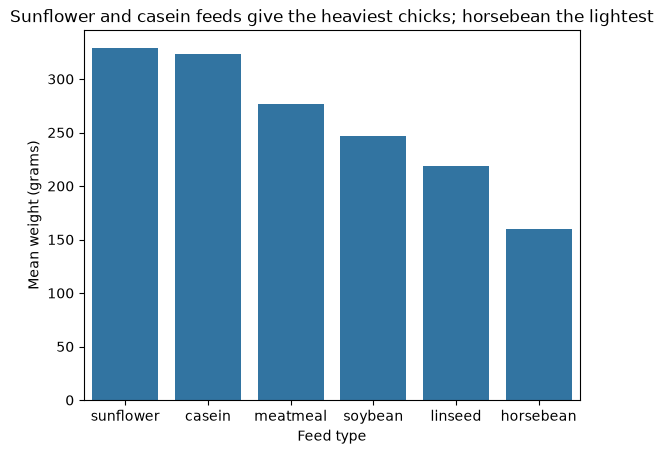

In [4]:
order = feed_means.sort_values(ascending=False).index   # tallest bar first
sns.barplot(data=chicks, x="feed", y="weight", order=order, errorbar=None)
plt.title("Sunflower and casein feeds give the heaviest chicks; horsebean the lightest")
plt.xlabel("Feed type")
plt.ylabel("Mean weight (grams)")
plt.show()

**Note:** In this data, sunflower (328.9 g) is slightly higher than casein (323.6 g), so casein is the second tallest bar. The two are very close. Horsebean is the lowest, as expected.

## Step 3: Histogram of all weights

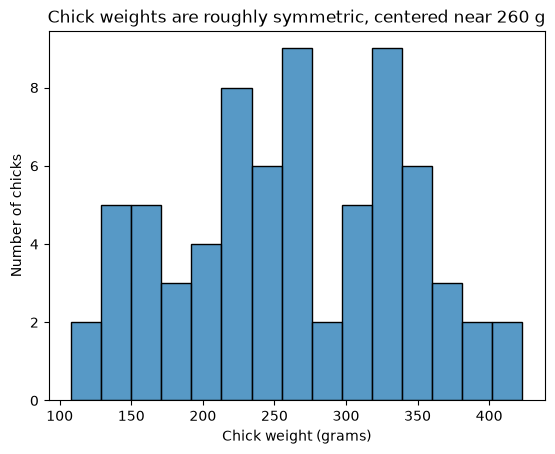

mean = 261.3 g, median = 258.0 g


In [5]:
sns.histplot(data=chicks, x="weight", bins=15)
plt.title("Chick weights are roughly symmetric, centered near 260 g")
plt.xlabel("Chick weight (grams)")
plt.ylabel("Number of chicks")
plt.show()
print("mean =", round(chicks["weight"].mean(), 1), "g, median =", chicks["weight"].median(), "g")

## Step 4: Line chart of museum visitors

In [6]:
museum = pd.read_csv("museum_visitors.csv", parse_dates=["Date"])
print(museum.head())
print(museum.shape)

        Date  Avila Adobe  Firehouse Museum  Chinese American Museum  America Tropical Interpretive Center
0 2014-01-01        24778              4486                     1581                                  6602
1 2014-02-01        18976              4172                     1785                                  5029
2 2014-03-01        25231              7082                     3229                                  8129
3 2014-04-01        26989              6756                     2129                                  2824
4 2014-05-01        36883             10858                     3676                                 10694
(59, 5)


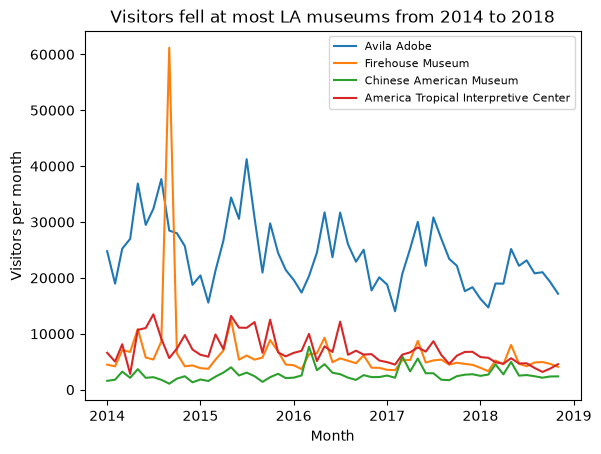

In [7]:
# the file has one column per museum, so reshape to long format for seaborn
long = museum.melt(id_vars="Date", var_name="Museum", value_name="Visitors")
sns.lineplot(data=long, x="Date", y="Visitors", hue="Museum")
plt.title("Visitors fell at most LA museums from 2014 to 2018")
plt.xlabel("Month")
plt.ylabel("Visitors per month")
plt.legend(fontsize=8)
plt.show()

In [8]:
# check the trend with numbers (total visitors per year)
yearly = museum.set_index("Date").sum(axis=1).groupby(lambda d: d.year).sum()
print(yearly)
print("Months of data in 2018:", (museum["Date"].dt.year == 2018).sum())

Date
2014    584874
2015    530791
2016    469123
2017    443151
2018    353464
dtype: int64
Months of data in 2018: 11


**Trend I see:** Total visitors fall almost every year, from about 585,000 in 2014 to about 443,000 in 2017 (2018 only has 11 months), and Avila Adobe is the busiest museum and has the biggest drop.

## Step 5: Scatter and heatmap on my Module 4 sales data

   order_id        date   product  price  qty    zip  revenue
0      1254  2026-04-06       mug  11.36    4  60614    45.44
1      1057  2026-05-30   charger  14.79    3  30303    44.37
2      1150  2026-05-06       mug   5.50    1  10001     5.50
3      1066  2026-05-30  notebook  37.53    1  98101    37.53
4      1114  2026-04-06    webcam  45.59    4  90405   182.36


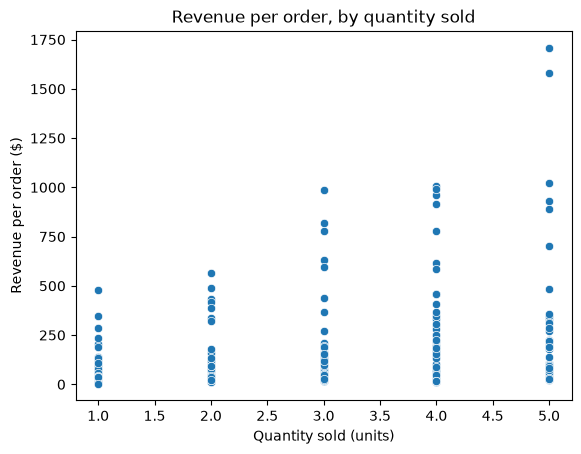

In [9]:
sales = pd.read_csv("sales_clean.csv")
sales["revenue"] = sales["price"] * sales["qty"]   # revenue = price x quantity
print(sales.head())

sns.scatterplot(data=sales, x="qty", y="revenue")
plt.title("Revenue per order, by quantity sold")
plt.xlabel("Quantity sold (units)")
plt.ylabel("Revenue per order ($)")
plt.show()

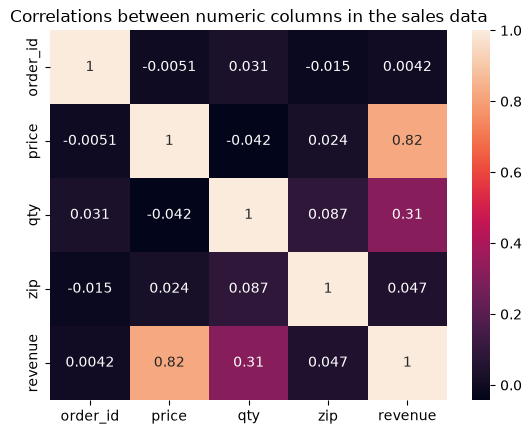

Strongest off-diagonal pair: ('price', 'revenue') r = 0.82
qty vs revenue: r = 0.31


In [10]:
corr = sales.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlations between numeric columns in the sales data")
plt.show()

# strongest correlation that is not a column with itself
pairs = corr.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
best = pairs.abs().sort_values(ascending=False).index[0]
print("Strongest off-diagonal pair:", best, "r =", round(corr.loc[best], 2))
print("qty vs revenue: r =", round(corr.loc["qty", "revenue"], 2))

**Strongest correlation:** price and revenue, r = 0.82. Quantity and revenue is weaker (r = 0.31), because quantity only ranges over a few small values while price varies a lot between products. (Revenue is calculated as price × qty, so it is expected to move with both.)

## Step 6: Hypothesis

**Null hypothesis (H0):** There is no difference in the average weight of chicks fed casein and chicks fed horsebean, so any gap we see is just random luck.

## Step 7: Run the t-test

In [11]:
a = chicks[chicks["feed"] == "casein"]["weight"]
b = chicks[chicks["feed"] == "horsebean"]["weight"]
print("n casein:", len(a), "| n horsebean:", len(b))
print("mean casein:", round(a.mean(), 1), "| mean horsebean:", round(b.mean(), 1))
print("difference (g):", round(a.mean() - b.mean(), 1))

result = ttest_ind(a, b)
print("t =", round(result.statistic, 2))
print("p =", result.pvalue)

n casein: 12 | n horsebean: 10
mean casein: 323.6 | mean horsebean: 160.2
difference (g): 163.4
t = 7.02
p = 8.254541016953186e-07


## Step 8: Conclusion

**Conclusion:** Chicks fed casein weighed about 163 g more on average than chicks fed horsebean (about 324 g vs 160 g), with t = 7.02 and p < 0.001 (p ≈ 0.0000008), so I reject the null hypothesis and conclude the difference is real and not just luck. One caution is that the sample is small (only 12 casein chicks and 10 horsebean chicks) and it comes from one farm experiment, so the result may not apply everywhere.

## Step 9: Honest-chart audit

**Chart audited:** the sorted bar chart of mean weight by feed (Step 2).
1. The y-axis starts at zero (I did not use `plt.ylim` to cut it), so the bar heights are not exaggerated.
2. The y-axis is labeled "Mean weight (grams)" with units, and the title states the takeaway, so the reader knows what is measured and what to notice.